# Graph Gallery for Inputs and Outputs

This notebook collects the most useful visualizations from the available AMR datasets in one place.

It focuses on three views:
- input dataset distributions from `data.csv` and `refined_data.csv`
- gene-feature patterns from the antibiotic-specific training tables
- output prediction behavior from `submission.csv`

Each plot is displayed inline and also saved to `graphs/`.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)

ROOT = Path('..').resolve()
GRAPH_DIR = ROOT / 'reports' / 'graphs'
GRAPH_DIR.mkdir(exist_ok=True)

def save_show(name: str):
    plt.tight_layout()
    plt.savefig(GRAPH_DIR / f'{name}.png', dpi=200, bbox_inches='tight')
    plt.show()

def resistant_fraction(series: pd.Series) -> float:
    s = series.astype(str).str.strip().str.lower()
    return (s == 'resistant').mean()

print(f'Graphs will be saved in: {GRAPH_DIR.resolve()}')

Graphs will be saved in: /Users/suvanghosh/IIT_HackBio-1/reports/graphs


## 2. Load Data

In [2]:
raw_df = pd.read_csv(ROOT / 'data' / 'raw' / 'data.csv')
refined_df = pd.read_csv(ROOT / 'data' / 'processed' / 'refined_data.csv')
submission_df = pd.read_csv(ROOT / 'data' / 'processed' / 'submission.csv')

feature_tables = {
    'ciprofloxacin': pd.read_csv(ROOT / 'data' / 'features' / 'ciprofloxacin_df.csv'),
    'gentamicin': pd.read_csv(ROOT / 'data' / 'features' / 'gentamicin_df.csv'),
    'meropenem': pd.read_csv(ROOT / 'data' / 'features' / 'meropenem_df.csv'),
}

print('raw_df:', raw_df.shape)
print('refined_df:', refined_df.shape)
print('submission_df:', submission_df.shape)
for antibiotic, df in feature_tables.items():
    print(f'{antibiotic}_df:', df.shape)

/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_21287/758408530.py:1: DtypeWarning: Columns (0: Source) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv(ROOT / 'data' / 'raw' / 'data.csv')


raw_df: (195795, 21)
refined_df: (95178, 16)
submission_df: (274, 7)
ciprofloxacin_df: (266, 315)
gentamicin_df: (277, 315)
meropenem_df: (239, 315)


In [3]:
overview = pd.DataFrame(
    {
        'dataset': ['raw', 'refined', 'submission'],
        'rows': [len(raw_df), len(refined_df), len(submission_df)],
        'columns': [raw_df.shape[1], refined_df.shape[1], submission_df.shape[1]],
    }
)
overview

,dataset,rows,columns
0,raw,195795,21
1,refined,95178,16
2,submission,274,7


## 3. Input Dataset Graphs

These plots summarize what goes into the modeling pipeline: antibiotic coverage, phenotype balance, measurement behavior, and lab metadata.

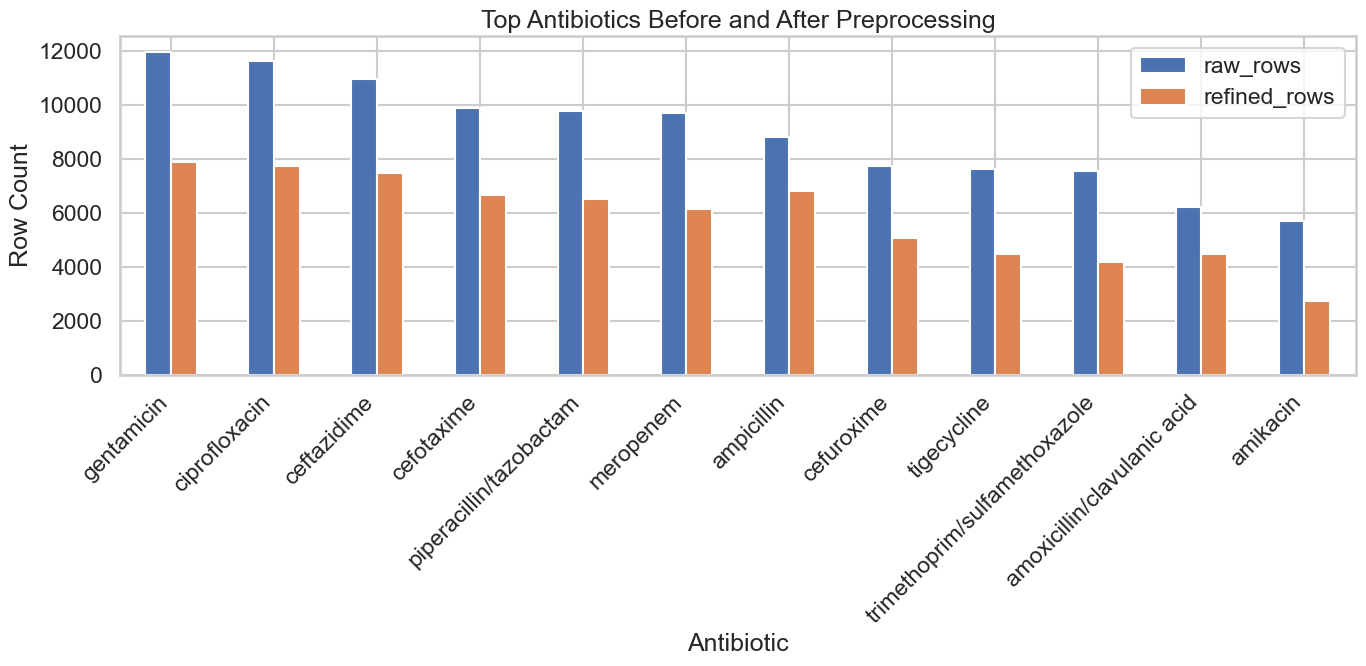

In [4]:
# Top antibiotics before and after preprocessing
raw_counts = raw_df['Antibiotic'].value_counts().head(12).rename('raw_rows')
refined_counts = refined_df['Antibiotic'].value_counts().head(12).rename('refined_rows')
compare_counts = pd.concat([raw_counts, refined_counts], axis=1).fillna(0).sort_values('raw_rows', ascending=False)

compare_counts.plot(kind='bar', figsize=(14, 7))
plt.title('Top Antibiotics Before and After Preprocessing')
plt.xlabel('Antibiotic')
plt.ylabel('Row Count')
plt.xticks(rotation=45, ha='right')
save_show('01_antibiotic_counts_raw_vs_refined')

/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_21287/2597318639.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_table, x='resistant_rate', y='Antibiotic', palette='magma')


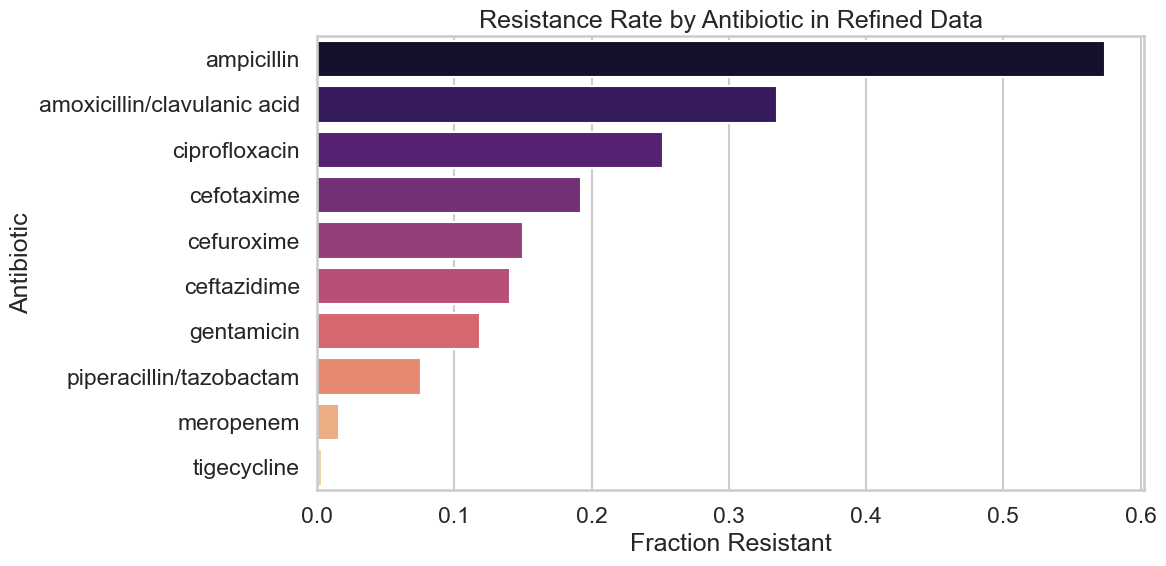

In [5]:
# Resistance rate for the most common antibiotics in the refined dataset
top_antibiotics = refined_df['Antibiotic'].value_counts().head(10).index
phenotype_view = refined_df[refined_df['Antibiotic'].isin(top_antibiotics)].copy()
phenotype_view = phenotype_view[phenotype_view['Resistant Phenotype'].isin(['Resistant', 'Susceptible'])]

rate_table = (
    phenotype_view.groupby('Antibiotic')['Resistant Phenotype']
    .apply(resistant_fraction)
    .sort_values(ascending=False)
    .reset_index(name='resistant_rate')
)

sns.barplot(data=rate_table, x='resistant_rate', y='Antibiotic', palette='magma')
plt.title('Resistance Rate by Antibiotic in Refined Data')
plt.xlabel('Fraction Resistant')
plt.ylabel('Antibiotic')
save_show('02_resistance_rate_by_antibiotic')

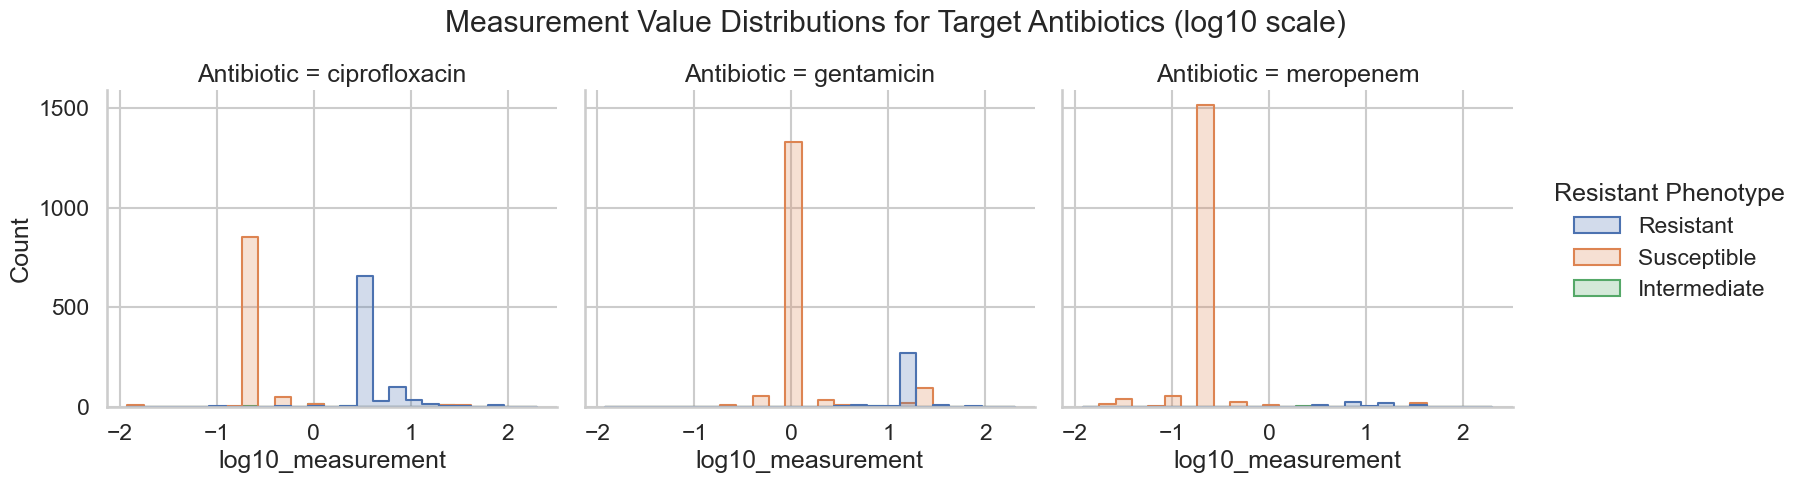

In [6]:
# Measurement value distributions for the three modeled antibiotics
measurement_view = refined_df[refined_df['Antibiotic'].str.lower().isin(['ciprofloxacin', 'gentamicin', 'meropenem'])].copy()
measurement_view['Measurement Value'] = pd.to_numeric(measurement_view['Measurement Value'], errors='coerce')
measurement_view = measurement_view.dropna(subset=['Measurement Value'])
measurement_view = measurement_view[measurement_view['Measurement Value'] > 0]
measurement_view['log10_measurement'] = np.log10(measurement_view['Measurement Value'])

g = sns.displot(
    data=measurement_view,
    x='log10_measurement',
    col='Antibiotic',
    hue='Resistant Phenotype',
    kind='hist',
    bins=25,
    element='step',
    common_norm=False,
    height=5,
    aspect=1.05,
)
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle('Measurement Value Distributions for Target Antibiotics (log10 scale)')
g.savefig(GRAPH_DIR / '03_measurement_distribution_target_antibiotics.png', dpi=200, bbox_inches='tight')
plt.show()

/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_21287/4068076637.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=standard_counts, x='count', y='Testing Standard', palette='crest')


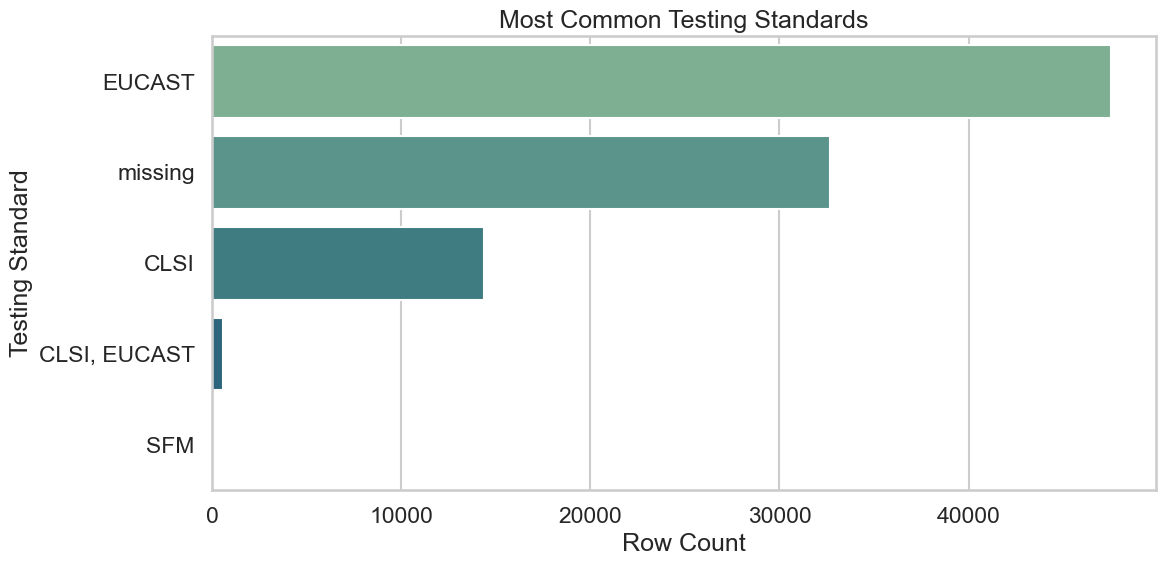

In [7]:
# Most common testing standards in the refined dataset
standard_counts = refined_df['Testing Standard'].fillna('Unknown').value_counts().head(12).reset_index()
standard_counts.columns = ['Testing Standard', 'count']

sns.barplot(data=standard_counts, x='count', y='Testing Standard', palette='crest')
plt.title('Most Common Testing Standards')
plt.xlabel('Row Count')
plt.ylabel('Testing Standard')
save_show('04_testing_standard_counts')

## 4. Gene-Level Input Feature Graphs

These plots inspect the model-ready gene matrices and highlight which AMR features are most common and most associated with resistance.

/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_21287/4285070745.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prevalence, x='presence_rate', y='gene', palette='viridis')


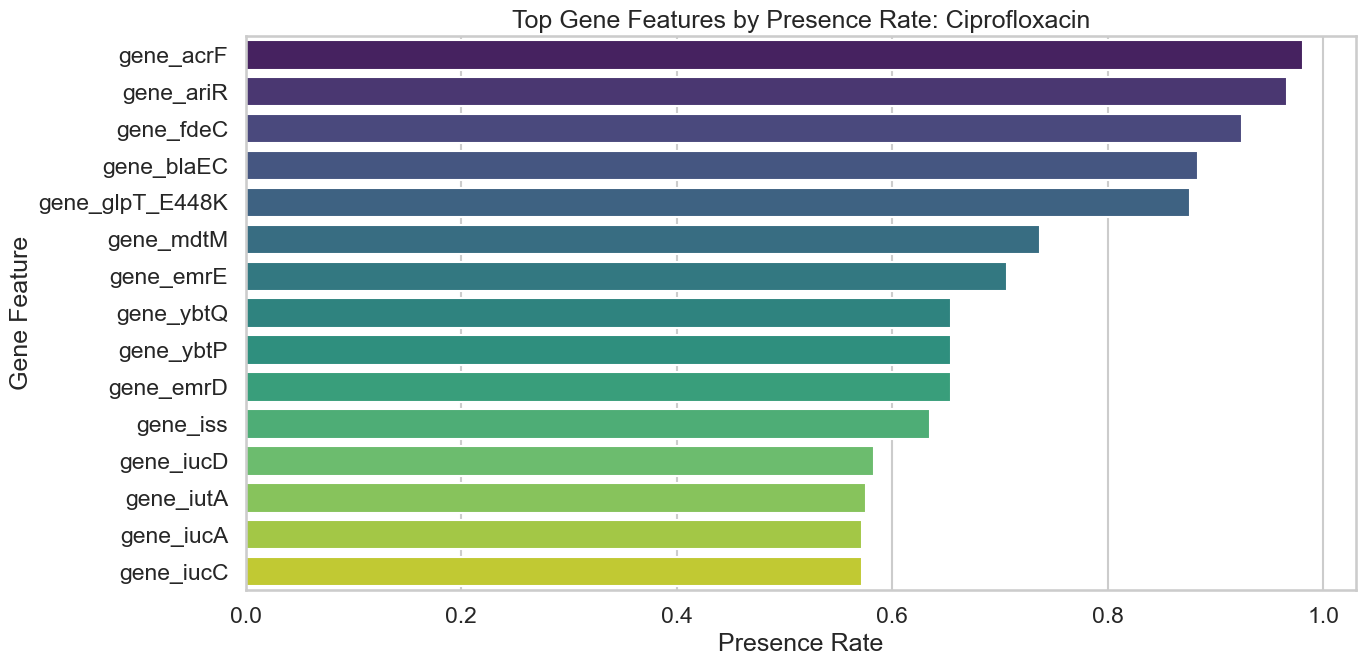

/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_21287/4285070745.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prevalence, x='presence_rate', y='gene', palette='viridis')


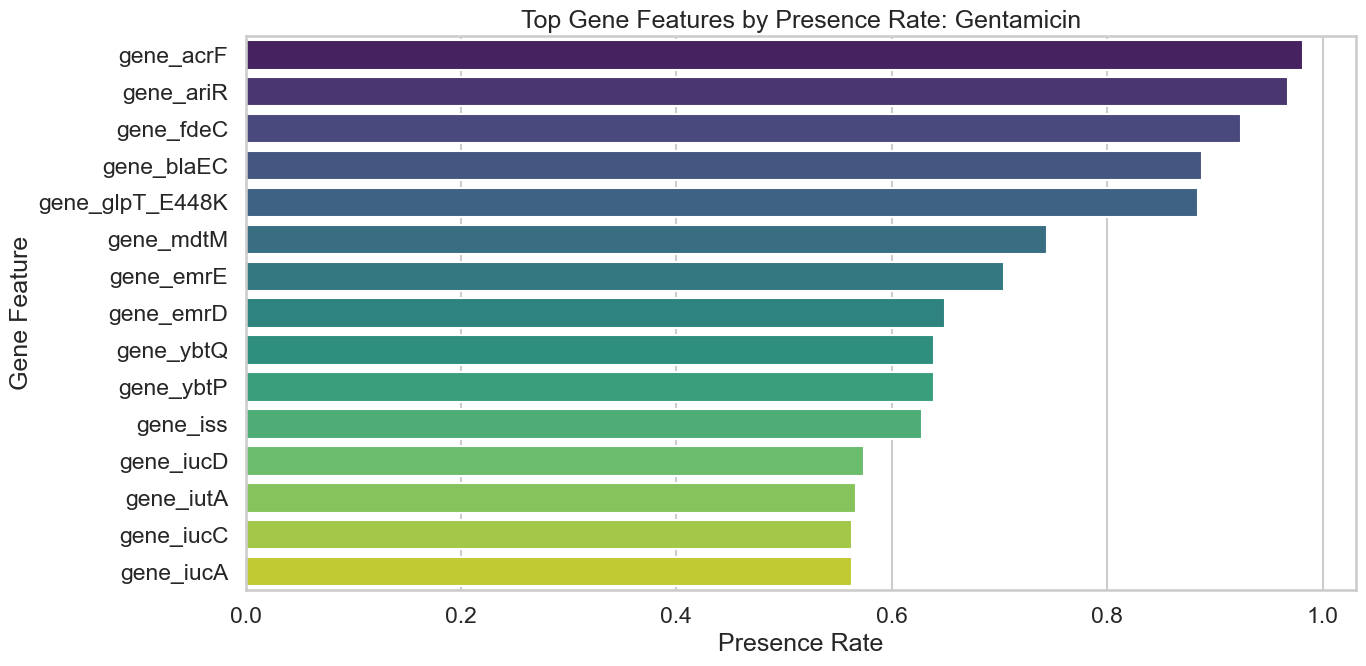

/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_21287/4285070745.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prevalence, x='presence_rate', y='gene', palette='viridis')


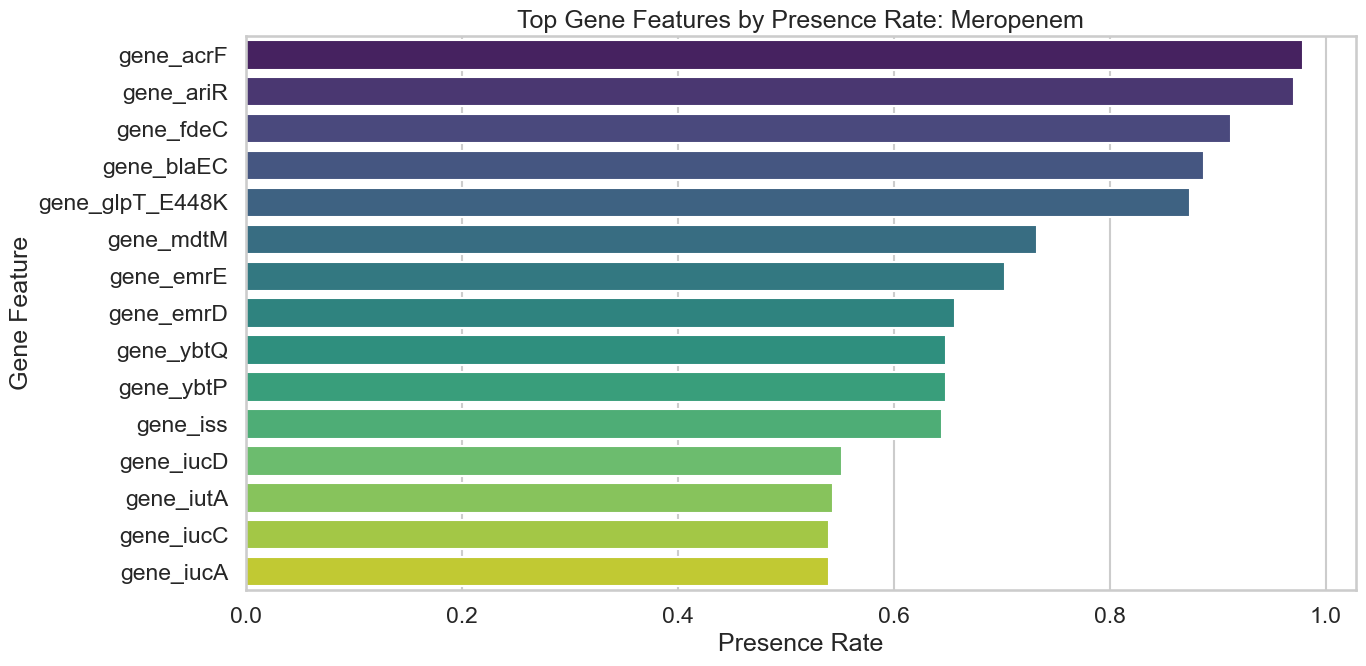

In [8]:
for antibiotic, df in feature_tables.items():
    gene_cols = [col for col in df.columns if col.startswith('gene_')]
    prevalence = df[gene_cols].mean().sort_values(ascending=False).head(15).reset_index()
    prevalence.columns = ['gene', 'presence_rate']

    plt.figure(figsize=(14, 7))
    sns.barplot(data=prevalence, x='presence_rate', y='gene', palette='viridis')
    plt.title(f'Top Gene Features by Presence Rate: {antibiotic.title()}')
    plt.xlabel('Presence Rate')
    plt.ylabel('Gene Feature')
    save_show(f'05_{antibiotic}_top_gene_prevalence')

/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_21287/1048783157.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diff, x='rate_gap', y='gene', palette='rocket')


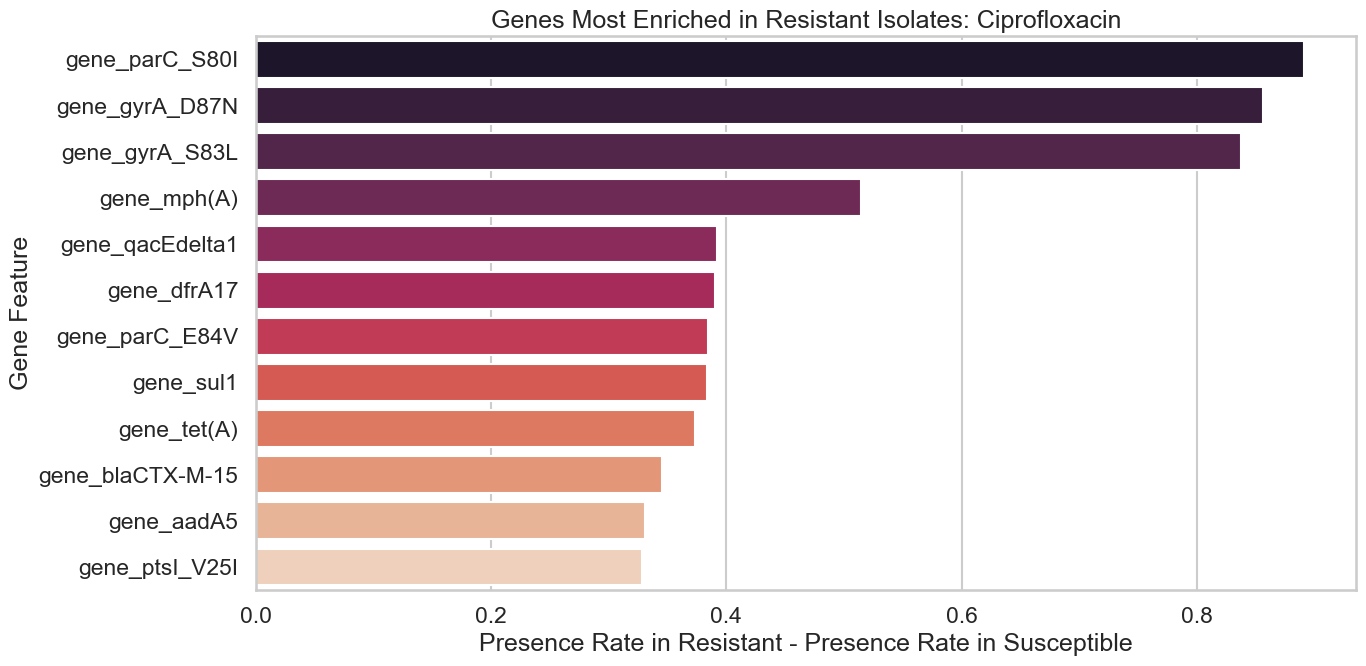

/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_21287/1048783157.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diff, x='rate_gap', y='gene', palette='rocket')


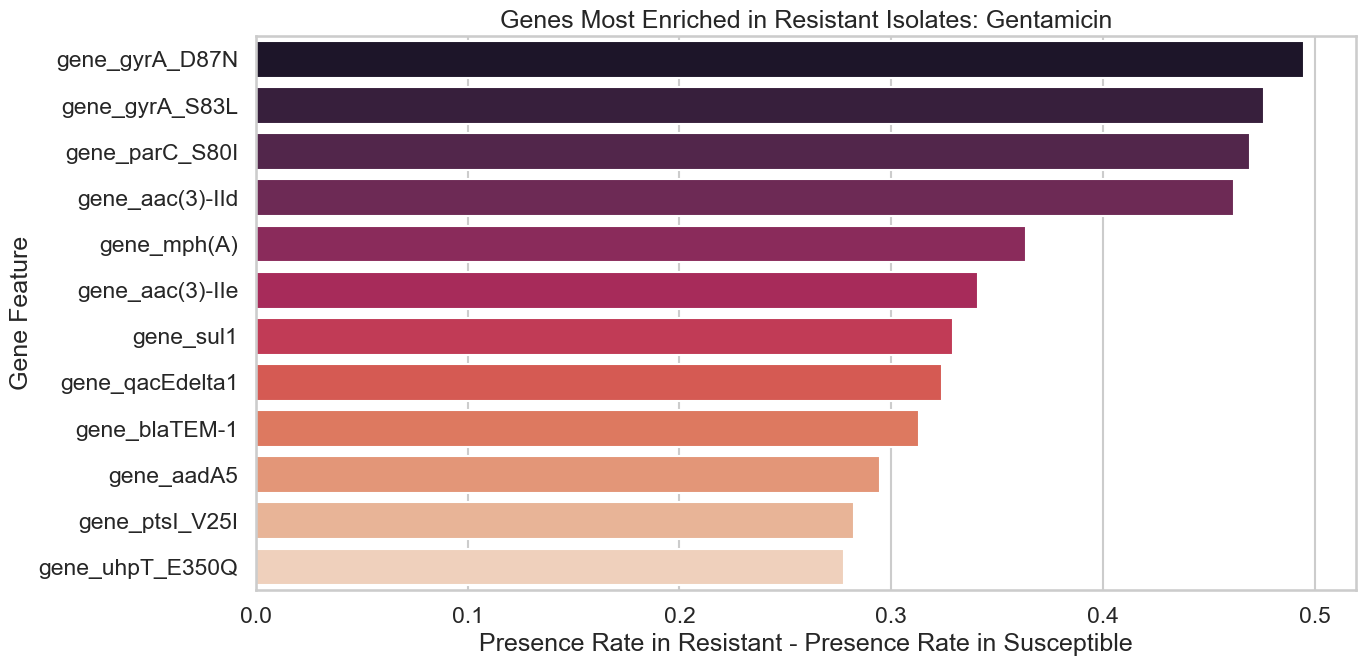

/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_21287/1048783157.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diff, x='rate_gap', y='gene', palette='rocket')


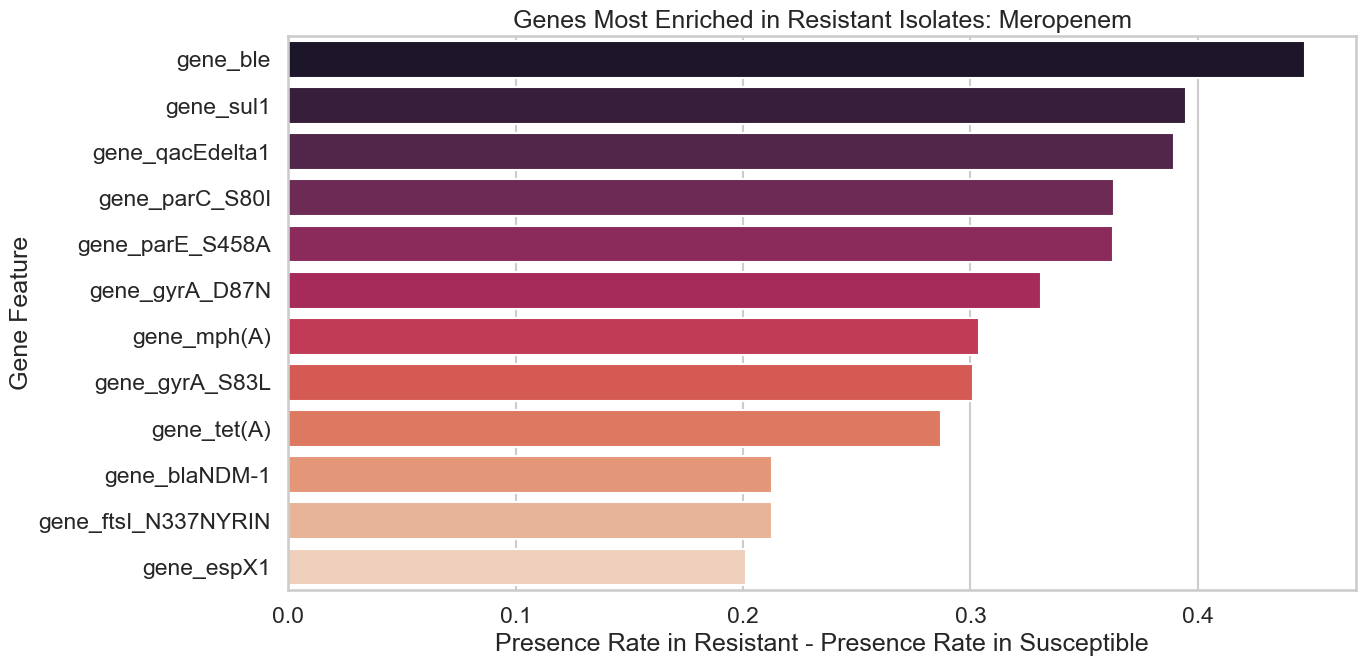

In [9]:
for antibiotic, df in feature_tables.items():
    gene_cols = [col for col in df.columns if col.startswith('gene_')]
    temp = df.copy()
    if 'Resistant_Binary' not in temp.columns:
        temp['Resistant_Binary'] = (temp['Resistant Phenotype'] == 'Resistant').astype(int)

    resistant_mean = temp.loc[temp['Resistant_Binary'] == 1, gene_cols].mean()
    susceptible_mean = temp.loc[temp['Resistant_Binary'] == 0, gene_cols].mean()
    diff = (resistant_mean - susceptible_mean).sort_values(ascending=False).head(12).reset_index()
    diff.columns = ['gene', 'rate_gap']

    plt.figure(figsize=(14, 7))
    sns.barplot(data=diff, x='rate_gap', y='gene', palette='rocket')
    plt.title(f'Genes Most Enriched in Resistant Isolates: {antibiotic.title()}')
    plt.xlabel('Presence Rate in Resistant - Presence Rate in Susceptible')
    plt.ylabel('Gene Feature')
    save_show(f'06_{antibiotic}_resistance_enriched_genes')

## 5. Output Prediction Graphs

These plots summarize the predictions that were finally produced for submission.

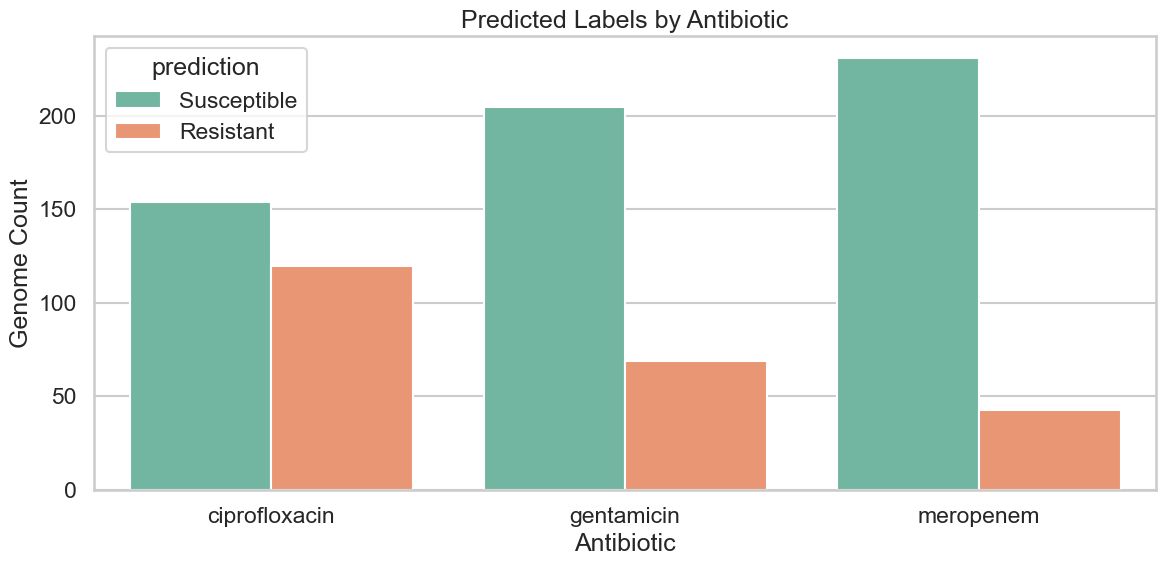

In [10]:
prediction_columns = [
    'ciprofloxacin_prediction',
    'gentamicin_prediction',
    'meropenem_prediction',
]

pred_long = submission_df.melt(
    id_vars='Genome ID',
    value_vars=prediction_columns,
    var_name='antibiotic',
    value_name='prediction',
)
pred_long['antibiotic'] = pred_long['antibiotic'].str.replace('_prediction', '', regex=False)

sns.countplot(data=pred_long, x='antibiotic', hue='prediction', palette='Set2')
plt.title('Predicted Labels by Antibiotic')
plt.xlabel('Antibiotic')
plt.ylabel('Genome Count')
save_show('07_prediction_label_counts')

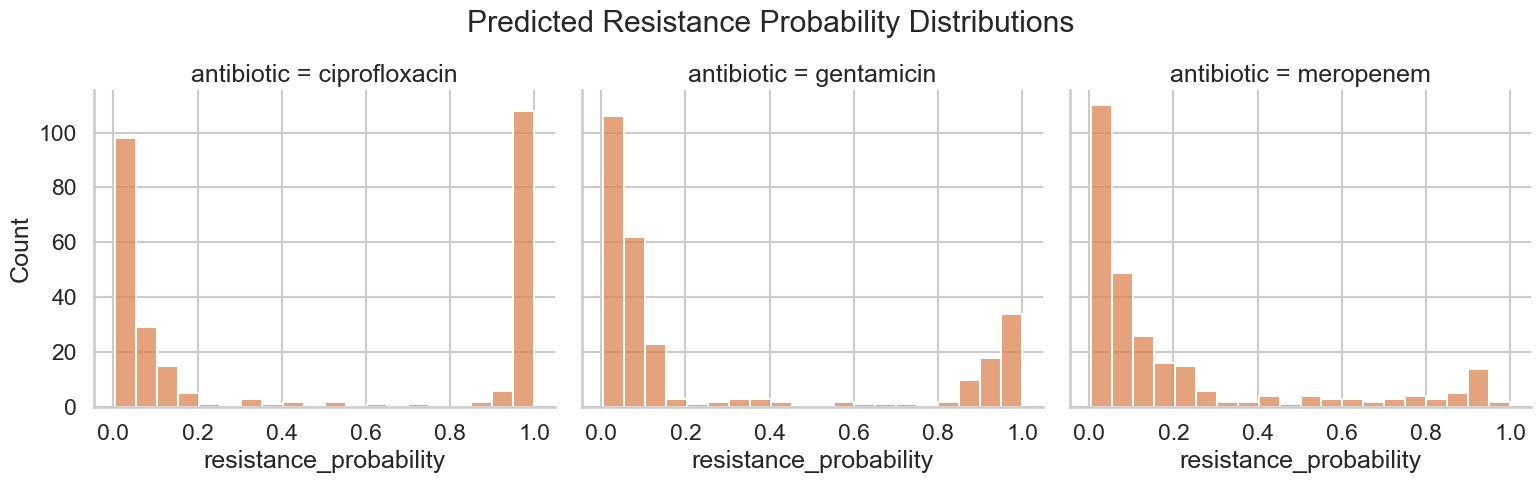

In [11]:
probability_columns = [
    'ciprofloxacin_resistance_probability',
    'gentamicin_resistance_probability',
    'meropenem_resistance_probability',
]

prob_long = submission_df.melt(
    id_vars='Genome ID',
    value_vars=probability_columns,
    var_name='antibiotic',
    value_name='resistance_probability',
)
prob_long['antibiotic'] = prob_long['antibiotic'].str.replace('_resistance_probability', '', regex=False)

g = sns.displot(
    data=prob_long,
    x='resistance_probability',
    col='antibiotic',
    kind='hist',
    bins=20,
    color='#dd8452',
    height=5,
    aspect=1.05,
)
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle('Predicted Resistance Probability Distributions')
g.savefig(GRAPH_DIR / '08_probability_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

/var/folders/80/wn8x154d6fn2js7st96hq8p00000gn/T/ipykernel_21287/2123283759.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=submission_df, x='predicted_resistant_count', palette='flare')


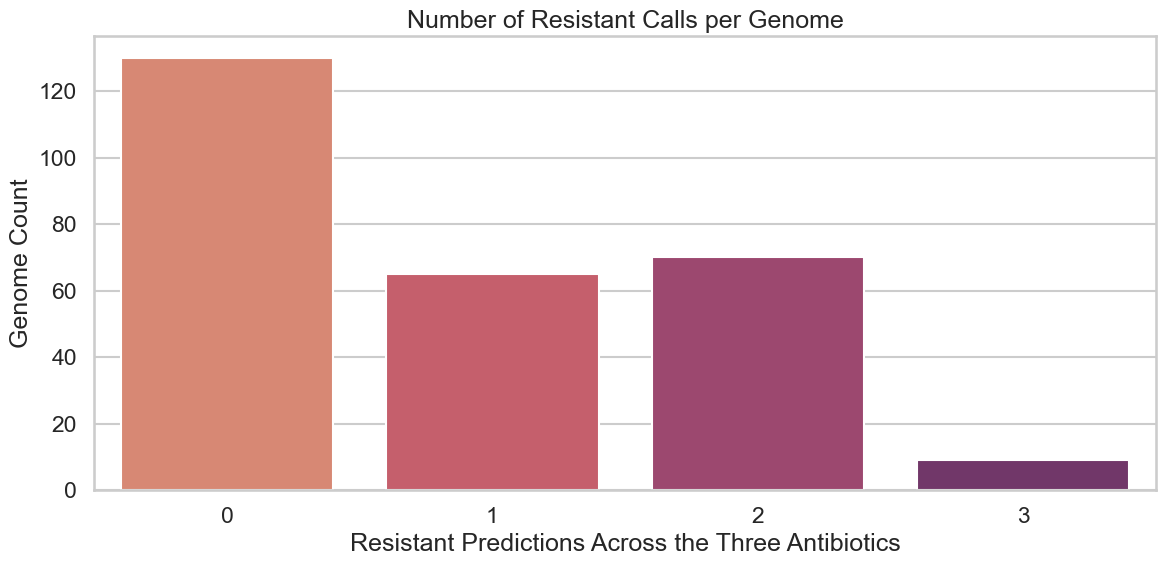

In [12]:
submission_df['predicted_resistant_count'] = (
    (submission_df['ciprofloxacin_prediction'] == 'Resistant').astype(int)
    + (submission_df['gentamicin_prediction'] == 'Resistant').astype(int)
    + (submission_df['meropenem_prediction'] == 'Resistant').astype(int)
)

sns.countplot(data=submission_df, x='predicted_resistant_count', palette='flare')
plt.title('Number of Resistant Calls per Genome')
plt.xlabel('Resistant Predictions Across the Three Antibiotics')
plt.ylabel('Genome Count')
save_show('09_resistant_calls_per_genome')

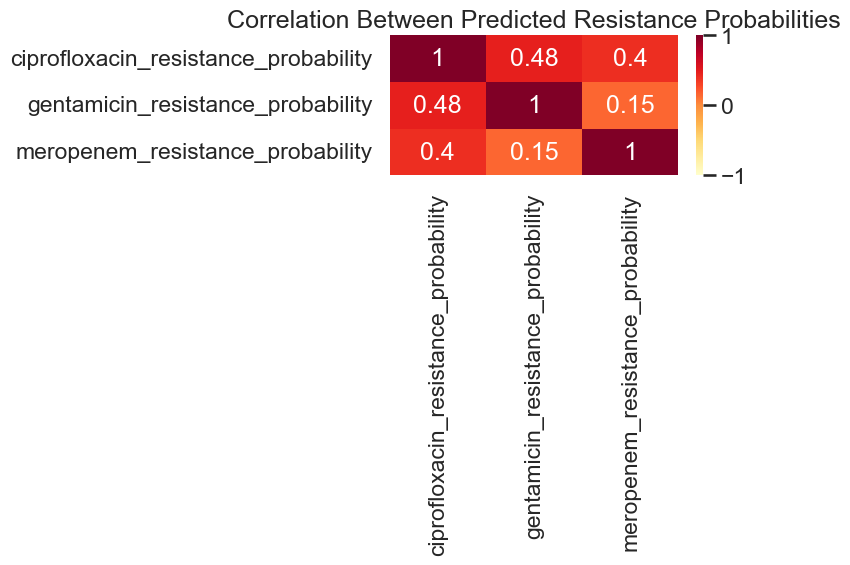

In [13]:
probability_matrix = submission_df[
    [
        'ciprofloxacin_resistance_probability',
        'gentamicin_resistance_probability',
        'meropenem_resistance_probability',
    ]
].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(probability_matrix, annot=True, cmap='YlOrRd', vmin=-1, vmax=1)
plt.title('Correlation Between Predicted Resistance Probabilities')
save_show('10_prediction_probability_correlation')

## 6. Quick Summary Table

In [14]:
summary_rows = []
for antibiotic in ['ciprofloxacin', 'gentamicin', 'meropenem']:
    summary_rows.append(
        {
            'antibiotic': antibiotic,
            'predicted_resistant': int((submission_df[f'{antibiotic}_prediction'] == 'Resistant').sum()),
            'predicted_susceptible': int((submission_df[f'{antibiotic}_prediction'] == 'Susceptible').sum()),
            'avg_resistance_probability': float(submission_df[f'{antibiotic}_resistance_probability'].mean()),
        }
    )

pd.DataFrame(summary_rows)

,antibiotic,predicted_resistant,predicted_susceptible,avg_resistance_probability
0,ciprofloxacin,120,154,0.460162
1,gentamicin,69,205,0.284019
2,meropenem,43,231,0.204372
